In [39]:
import numpy as np
import pandas as pd

In [40]:
df= pd.read_csv("/content/exchange_rate.csv")

In [41]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [42]:
df.shape

(7588, 2)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [44]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [45]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.columns

Index(['date', 'Ex_rate'], dtype='object')

In [48]:
df['date'].head(10)

,date
0,01-01-1990 00:00
1,02-01-1990 00:00
2,03-01-1990 00:00
3,04-01-1990 00:00
4,05-01-1990 00:00
5,06-01-1990 00:00
6,07-01-1990 00:00
7,08-01-1990 00:00
8,09-01-1990 00:00
9,10-01-1990 00:00


In [49]:
df['date']=pd.to_datetime(df['date'],format='%d-%m-%Y %H:%M')


In [50]:
df.dtypes

,0
date,datetime64[ns]
Ex_rate,float64


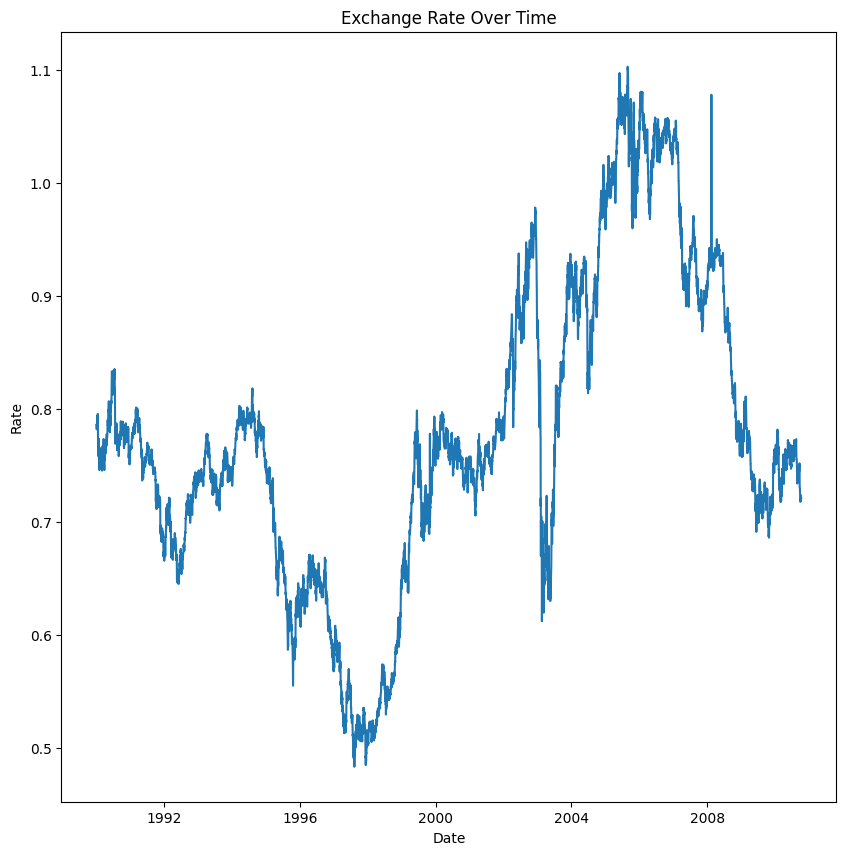

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))
plt.plot(df['date'],df['Ex_rate'])
plt.xlabel('Date')
plt.ylabel('Rate')
plt.title('Exchange Rate Over Time')
plt.show()



In [52]:
df.isnull().sum()

,0
date,0
Ex_rate,0


In [53]:
df['Ex_rate'].describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [54]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Ex_rate'])

print("p-value:", result[1])

p-value: 0.4492327353597477


In [55]:
df['Ex_rate']=df['Ex_rate'].diff()

In [56]:
df['Ex_rate_diff']=df['Ex_rate'].dropna()

In [57]:
df_diff=df['Ex_rate_diff'].dropna()

In [58]:
diff_result = adfuller(df_diff)

print("p-value:", diff_result[1])

p-value: 0.0


In [60]:
df = pd.read_csv("exchange_rate.csv")

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

df['Ex_rate_diff'] = df['Ex_rate'].diff()

df_diff = df['Ex_rate_diff'].dropna()

In [61]:
diff_result=adfuller(df_diff)

print("p-value:",diff_result[1])

p-value: 0.0


<Figure size 1000x500 with 0 Axes>

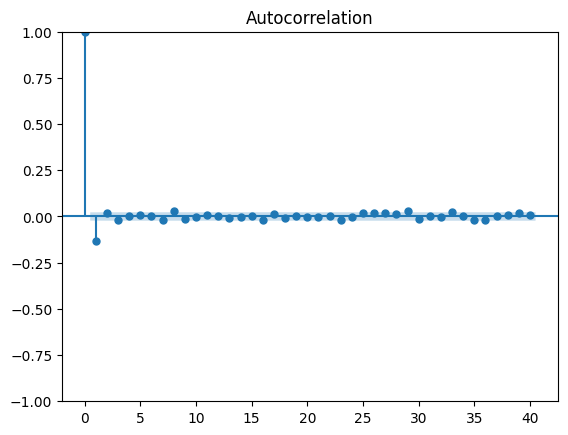

In [64]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(df_diff,lags=40)
plt.show()

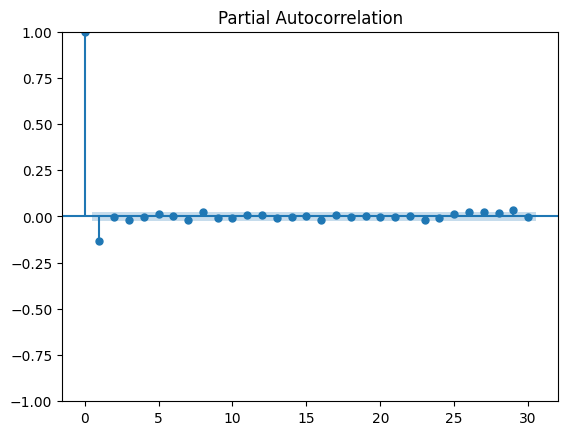

In [65]:
plot_pacf(df_diff,lags=30)
plt.show()

In [73]:
from statsmodels.tsa.arima.model import ARIMA

In [74]:
model=ARIMA(df_diff,order=(1,1,1))
model_fit=model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Ex_rate_diff   No. Observations:                 7587
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28041.562
Date:                Wed, 02 Sep 2026   AIC                         -56077.124
Time:                        05:44:14   BIC                         -56056.322
Sample:                             0   HQIC                        -56069.985
                               - 7587                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1325      0.002    -60.233      0.000      -0.137      -0.128
ma.L1         -1.0000      0.078    -12.819      0.000      -1.153      -0.847
sigma2       3.59e-05   2.77e-06     12.971      0.0

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [77]:
model= ARIMA(df['Ex_rate'], order=(1,1,1))

model_fit.model.fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [78]:
residuals=pd.DataFrame(model_fit.resid)

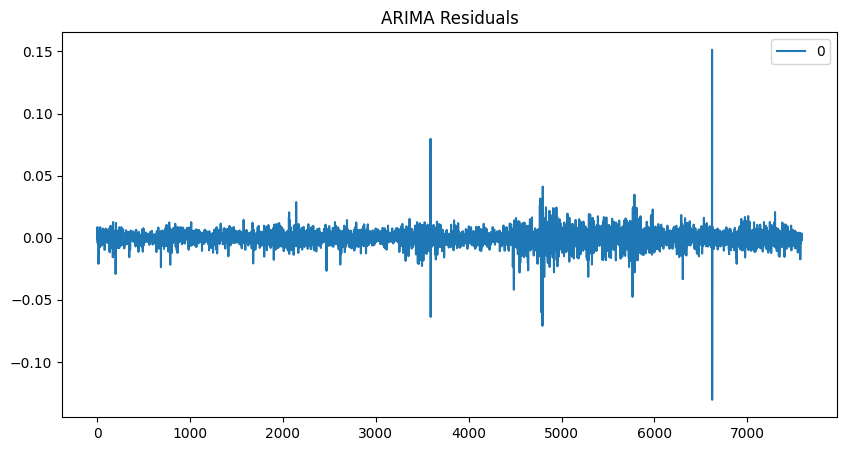

In [80]:
residuals.plot(figsize=(10,5))
plt.title('ARIMA Residuals')
plt.show()

In [81]:
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]

In [84]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

In [86]:
pred =model_fit.forecast(steps=30)

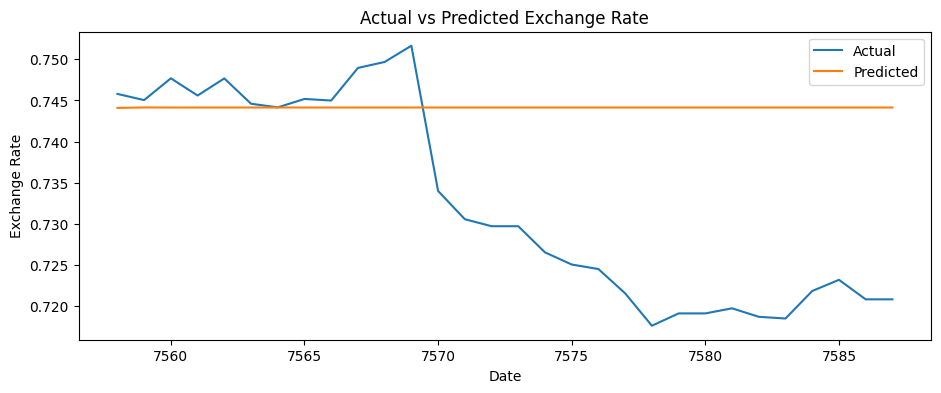

In [97]:
plt.figure(figsize=(11,4))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted')

plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Actual vs Predicted Exchange Rate')
plt.legend()

plt.show()

In [89]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [91]:
mae =mean_absolute_error(test,pred)
print("MAE:",mae)

mse=mean_squared_error(test,pred)
print("MSE:",mse)

rmse=np.sqrt(mse)
print("RMSE:",rmse)

mape=np.mean(np.abs((test-pred)/test))*100
print("MAPE:",mape)

MAE: 0.013494600805886207
MSE: 0.0002766293421335502
RMSE: 0.016632177913116195
MAPE: 1.8632207485601178


In [92]:
comparsion=pd.DataFrame({'Actual':test,'Predicted':pred})

In [93]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [94]:
model_es =ExponentialSmoothing(train).fit()

In [95]:
pred_es =model_es.forecast(steps=30)

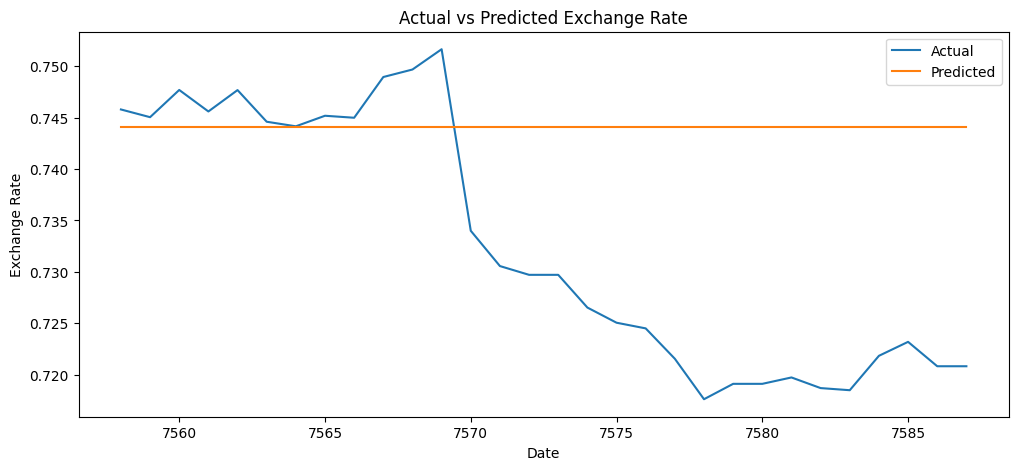

In [96]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred_es, label='Predicted')

plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('Actual vs Predicted Exchange Rate')
plt.legend()

plt.show()

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_es = mean_absolute_error(test, pred_es)

mse_es = mean_squared_error(test, pred_es)
rmse_es = np.sqrt(mse_es)

mape_es = np.mean(np.abs((test - pred_es) / test)) * 100

print("MAE:", mae_es)
print("RMSE:", rmse_es)
print("MAPE:", mape_es, "%")

MAE: 0.013479302076630261
RMSE: 0.016584775578591723
MAPE: 1.8609926262918224 %


Model Comparison:
ARIMA and Exponential Smoothing were used to forecast the exchange rate. The models were evaluated using MAE, RMSE, and MAPE. ARIMA produced a MAE of 0.01349, RMSE of 0.01663, and MAPE of 1.8632%. Exponential Smoothing produced a MAE of 0.01348, RMSE of 0.01658, and MAPE of 1.8610%. Since lower error values indicate better

Conclusion:
In this analysis, ARIMA and Exponential Smoothing were applied to forecast exchange rates. The data was prepared, explored, tested for stationarity, and evaluated using MAE, RMSE, and MAPE. The results showed that Exponential Smoothing achieved slightly lower MAE, RMSE, and MAPE values than ARIMA. Therefore, Exponential Smoothing provided the best forecasting performance for this dataset.